# Volve Field Notebook 3: Pressure Diagnosis

Probes *why* by reading signals together.

Two questions :
did the water-injection scheme hold Volve's reservoir pressure to the end?
why did the late-life pressure rise on the main producer; reservoir (injection) or by operations (choke)?

**The approach:** field-level question, answered with all producers for the pressure trend.
Producer F-14 H (the only continuously monitored well) for the pressure-vs-choke diagnosis.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/volve_daily_clean.csv", parse_dates=["Date"]) #read data

df["Well"] = df["Well"].str.replace("NO 15/9-", "", regex=False) # rename wells to make labelling cleaner

#producing = df[(df["Well Role"] == "Producer") & (df["On Stream Hours"] > 0)] #filter by producer & on-stream hours > 0

producing = df[(df["Well Role"] == "Producer") & (df["On Stream Hours"] > 23)] #filter by producer & on-stream hours > 23 for full day

producing.shape


(7190, 28)

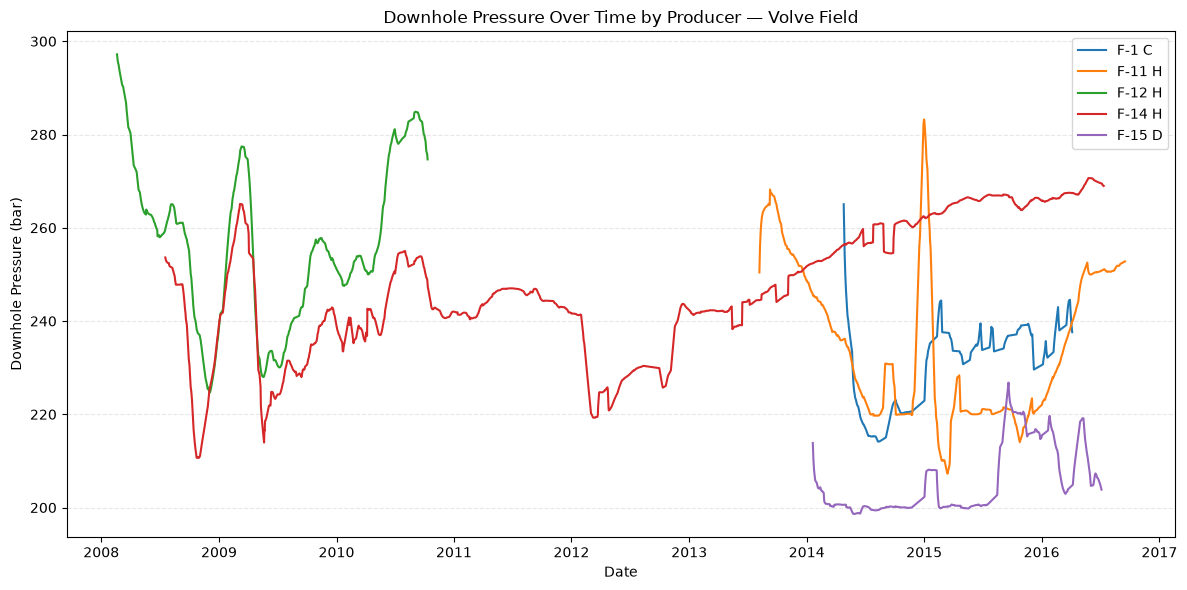

In [5]:
# Chart 1: Downhole Pressure, all producers
# Keep only readings > 0 bar: 0 bar at ~3 km depth is a failed gauge, not measured (hydrostatic pressure alone = hundreds of bar).
# F-12 H's gauge failed late 2010 (line stops there)
# F-5 AH never had a valid reading, so it drops out.

pressure_data = producing[producing["Downhole Pressure"] > 0]

plt.figure(figsize=(12, 6))

for well in pressure_data["Well"].unique():
    one_well = pressure_data[pressure_data["Well"] == well].sort_values("Date")
    smooth = one_well.set_index("Date")["Downhole Pressure"].rolling(30, min_periods=5).mean()
    plt.plot(smooth.index, smooth.values, label=well)

plt.title("Downhole Pressure Over Time by Producer — Volve Field")
plt.ylabel("Downhole Pressure (bar)")
plt.xlabel("Date")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig("../images/downhole-pressure-by-producer.png", dpi=350)
plt.show()


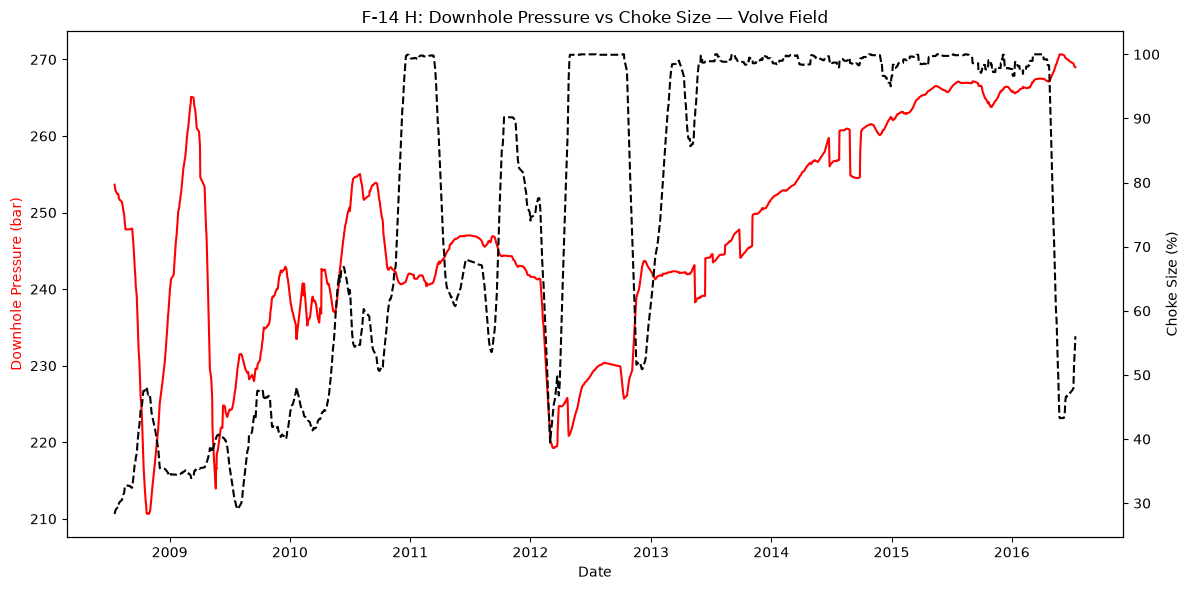

In [6]:
# Chart 2: F-14 H Pressure vs Choke
# Flowing pressure = reservoir pressure − drawdown
# Injection raises reservoir pressure flowing pressure rises with it (reservoir effect)
# Choke closes and flow rate drops = drawdown shrinks and flowing pressure climbs toward reservoir pressure (operational effect)


f14 = producing[(producing["Well"] == "F-14 H") & (producing["Downhole Pressure"] > 0)].sort_values("Date")

pressure_smooth = f14.set_index("Date")["Downhole Pressure"].rolling(30, min_periods=5).mean()
choke_smooth = f14.set_index("Date")["Choke Size"].rolling(30, min_periods=5).mean()

fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(pressure_smooth.index, pressure_smooth.values, color="red", label="Downhole Pressure")
ax1.set_ylabel("Downhole Pressure (bar)", color="red")
ax1.set_xlabel("Date")

ax2 = ax1.twinx() #creates a second y-axis sharing the same dates
ax2.plot(choke_smooth.index, choke_smooth.values, color="black", linestyle="--", label="Choke Size")
ax2.set_ylabel("Choke Size (%)", color="black")

plt.title("F-14 H: Downhole Pressure vs Choke Size — Volve Field")
fig.tight_layout()
plt.savefig("../images/f14-pressure-vs-choke.png", dpi=350)
plt.show()

From 2012 to shutdown, F-14 H's choke was 90–100% while downhole pressure rose ~35 bar (210-245).
Since the choke was not being closed, the rise cannot be a drawdown effect
it points to reservoir pressure being maintained by injection,
compounded by an increasingly water-heavy (denser) fluid column as water cut approached 97%.

## Conclusion: field-level

Downhole pressure held or rose across every gauged producer for eight years, and F-14 H's
~35 bar rise from 2012 to shutdown occurred at 90–100% choke. Not a drawdown
effect, and points instead to reservoir pressure maintained by injection, with an
increasingly water-heavy (denser) fluid column adding to the reading as water cut
approached 97%.

Read together with the flat GOR of Notebook 2 (135–170 Sm³/Sm³), no gas breakout in eight
years. The two independent signals agree: the waterflood held the reservoir's energy to the end.

Volve died of water, not of pressure loss.
 F-14 H was produced at essentially full choke (90–100%) through its final four years (2012-2016) 
 and still watered out (produced water at 70-97%),it drowned at full throttle. 
Rising water cut, not reservoir depletion, ended the field in 2016: this signature means the waterflood did its job.

## What next in repo (SQL): approximate voidage replacement ratio (VRR)

This notebook shows pressure *held*. It does not show *why* in volume terms.
whether injection actually replaced the reservoir volume that production removed (VRR)

VRR = reservoir volume injected ÷ reservoir volume produced

VRR ≈ 1 means voidage is being replaced and pressure should hold, inferred by pressure trend above.